# Physical Verification of Dirac Solver
    
This notebook demonstrates the validity of the `dirac_solver` library by performing three standard physical tests:
1.  **Free Particle Plane Wave Evolution:** Checking phase accumulation.
2.  **Conservation of Probability:** Verifying unitarity.
3.  **Conservation of Energy:** Verifying time-translation invariance (approximately).


In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Add the parent directory to sys.path to locate dirac_solver
sys.path.append(os.path.abspath('..'))

from dirac_solver import (
    Grid,
    ConstantSpinor,
    PlaneWave,
    GaussianPacket,
    DiracProblemBuilder,
    DiracSolver,
    _core,
    observables,
)

# Set larger font size for plots
plt.rcParams.update({'font.size': 14})

## 1. Free Particle Plane Wave Evolution
    
We initialize a plane wave $\psi(x) \propto e^{i p x}$ and evolve it in time. 
For a free particle, the solution should be $\psi(x, t) = \psi(x, 0) e^{-i E t}$, where $E = \sqrt{p^2 + m^2}$.
We will verify that the numerical solution matches this analytical expectation.

<>:55: SyntaxWarning: invalid escape sequence '\p'
<>:55: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_5130/1101266378.py:55: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel("Re($\psi_0$)")


DiracSolver inicializado con el motor C++ 'FDTDLeapfrogIntegrator'.
Ejecutando simulación por 1000 pasos...
  Paso 10/1000 completado.
  Paso 20/1000 completado.
  Paso 30/1000 completado.
  Paso 40/1000 completado.
  Paso 50/1000 completado.
  Paso 60/1000 completado.
  Paso 70/1000 completado.
  Paso 80/1000 completado.
  Paso 90/1000 completado.
  Paso 100/1000 completado.
  Paso 110/1000 completado.
  Paso 120/1000 completado.
  Paso 130/1000 completado.
  Paso 140/1000 completado.
  Paso 150/1000 completado.
  Paso 160/1000 completado.
  Paso 170/1000 completado.
  Paso 180/1000 completado.
  Paso 190/1000 completado.
  Paso 200/1000 completado.
  Paso 210/1000 completado.
  Paso 220/1000 completado.
  Paso 230/1000 completado.
  Paso 240/1000 completado.
  Paso 250/1000 completado.
  Paso 260/1000 completado.
  Paso 270/1000 completado.
  Paso 280/1000 completado.
  Paso 290/1000 completado.
  Paso 300/1000 completado.
  Paso 310/1000 completado.
  Paso 320/1000 completado.
  Pas

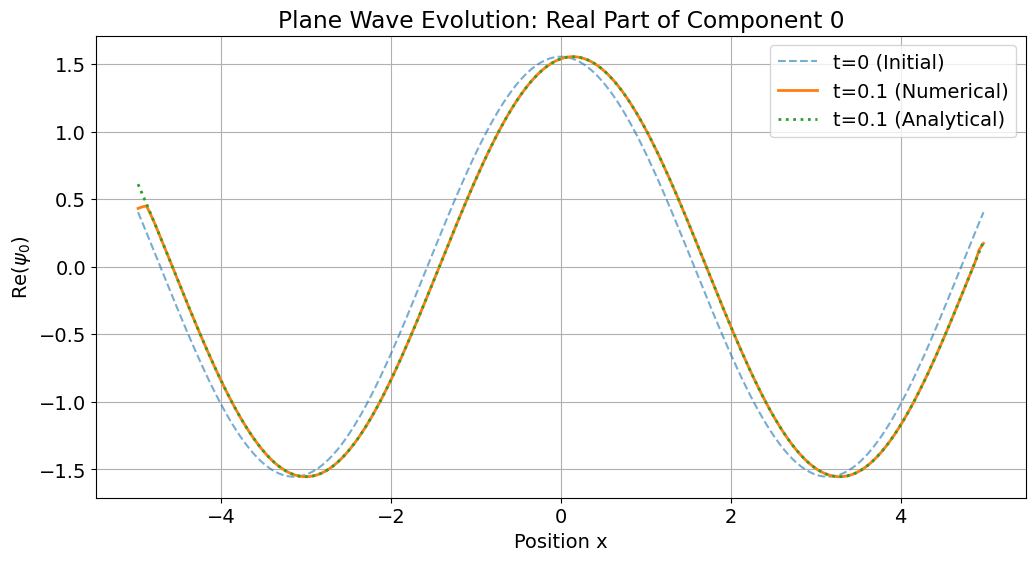

In [2]:
# Parameters
L = 10.0
N = 200
dx = L / N
grid = Grid(shape=(N,), spacing=(dx,))

px = 1.0
momentum = [px, 0.0, 0.0]
mass = 1.0

# Setup Initial State
constant_spinor = ConstantSpinor(momentum=momentum, mass=mass)
initial_state = PlaneWave(constant_spinor)

# Setup Problem
problem = (
    DiracProblemBuilder()
    .set_grid(grid)
    .set_initial_state(initial_state)
    .set_potential(_core.FreeParticle())
    .set_boundary_condition(_core.PeriodicBoundary())
    .set_time_parameters(time_step=0.0001, total_time=0.1)
    .build()
)

# Run Solver
solver = DiracSolver(problem)
psi_0 = solver.get_psi()
solver.run_simulation()
psi_t = solver.get_psi()

# Analytical Solution
E = np.sqrt(px**2 + mass**2)
phase_factor = np.exp(-1j * E * problem.total_time)
psi_analytical = psi_0 * phase_factor

# Calculate Error
diff = psi_t - psi_analytical
rel_error = np.linalg.norm(diff) / np.linalg.norm(psi_analytical)

print(f"Relative L2 Error: {rel_error:.4f}")

# Visualization
psi_real_0 = psi_0[:, 0].real
psi_real_t = psi_t[:, 0].real
psi_real_ana = psi_analytical[:, 0].real
x = grid.coords[:, 0]

plt.figure(figsize=(12, 6))
plt.plot(x, psi_real_0, '--', label='t=0 (Initial)', alpha=0.6)
plt.plot(x, psi_real_t, '-', label='t=0.1 (Numerical)', linewidth=2)
plt.plot(x, psi_real_ana, ':', label='t=0.1 (Analytical)', linewidth=2)
plt.legend()
plt.xlabel("Position x")
plt.ylabel("Re($\psi_0$)")
plt.title("Plane Wave Evolution: Real Part of Component 0")
plt.grid(True)
plt.show()

## 2. Conservation of Probability
    
The Dirac equation preserves the norm of the wavefunction (unitarity). 
We simulate a Gaussian packet and verify that $\int |\psi|^2 dV$ remains constant.

DiracSolver inicializado con el motor C++ 'FDTDLeapfrogIntegrator'.


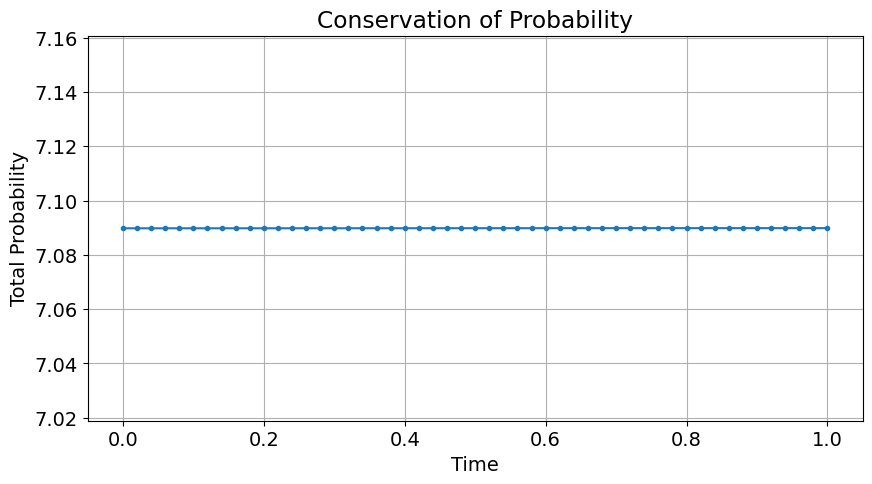

Initial Probability: 7.089811
Final Probability: 7.089868
Max Deviation: 5.68e-05


In [3]:
# Parameters
grid = Grid(shape=(100,), spacing=(0.1,))
initial_state = GaussianPacket(
    ConstantSpinor(momentum=[1.0, 0, 0]), 
    center=[0.0, 0, 0], 
    spatial_width=1.0
)

dt = 0.002
total_time = 1.0
problem = (
    DiracProblemBuilder()
    .set_grid(grid)
    .set_initial_state(initial_state)
    .set_potential(_core.FreeParticle())
    .set_boundary_condition(_core.PeriodicBoundary())
    .set_time_parameters(time_step=dt, total_time=total_time)
    .build()
)

solver = DiracSolver(problem)
obs = observables.Observables(solver)

# Simulation Loop with Observable Tracking
times = []
probs = []
num_steps = int(total_time / dt)

# Initial value
times.append(0.0)
rho = obs.probability_density(solver.get_psi())
probs.append(np.sum(rho) * grid.get_cell_volume())

for i in range(num_steps):
    solver.integrator.step()
    if (i+1) % 10 == 0:
        t = (i+1) * dt
        times.append(t)
        rho = obs.probability_density(solver.get_psi())
        probs.append(np.sum(rho) * grid.get_cell_volume())

# Plot
plt.figure(figsize=(10, 5))
plt.plot(times, probs, '.-')
plt.xlabel("Time")
plt.ylabel("Total Probability")
plt.title("Conservation of Probability")
plt.ylim(min(probs)*0.99, max(probs)*1.01)
plt.grid(True)
plt.show()

print(f"Initial Probability: {probs[0]:.6f}")
print(f"Final Probability: {probs[-1]:.6f}")
print(f"Max Deviation: {np.max(np.abs(np.array(probs) - probs[0])):.2e}")

## 3. Conservation of Energy
    
For a time-independent Hamiltonian, energy expectation value $\langle H angle$ should be conserved.
Numerical schemes like Leapfrog may show small oscillations or drift, but should remain stable.

DiracSolver inicializado con el motor C++ 'FDTDLeapfrogIntegrator'.


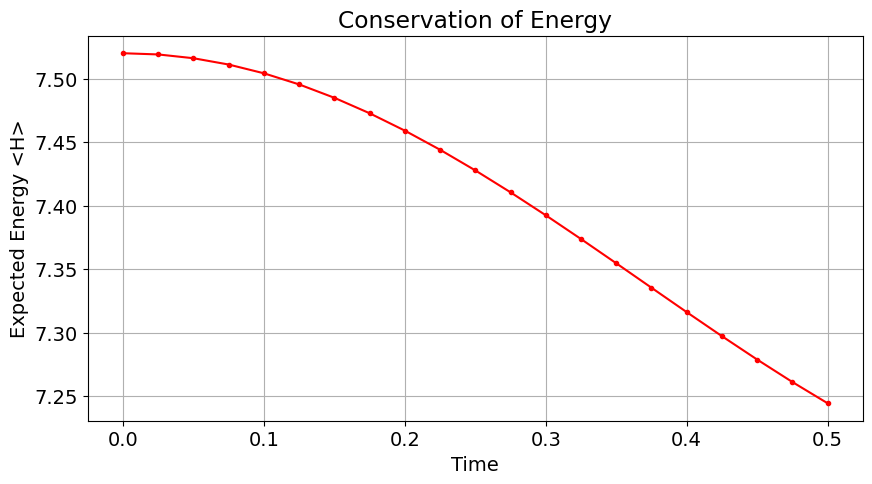

Initial Energy: 7.5199
Final Energy: 7.2446
Relative Error: 0.0366


In [4]:
# Parameters
# Use wider grid to avoid boundary effects for energy calculation
grid = Grid(shape=(200,), spacing=(0.1,)) 
initial_state = GaussianPacket(
    ConstantSpinor(momentum=[1.0, 0, 0]), 
    center=[0.0, 0, 0], 
    spatial_width=1.5
)

dt = 0.0005
total_time = 0.5

problem = (
    DiracProblemBuilder()
    .set_grid(grid)
    .set_initial_state(initial_state)
    .set_potential(_core.FreeParticle())
    .set_boundary_condition(_core.PeriodicBoundary())
    .set_time_parameters(time_step=dt, total_time=total_time)
    .build()
)

solver = DiracSolver(problem)
obs = observables.Observables(solver)

times = []
energies = []
num_steps = int(total_time / dt)

# Initial
times.append(0.0)
energies.append(obs.expected_value_energy(solver.get_psi()))

# Loop
for i in range(num_steps):
    solver.integrator.step()
    if (i+1) % 50 == 0:
        t = (i+1) * dt
        times.append(t)
        energies.append(obs.expected_value_energy(solver.get_psi()))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(times, energies, '.-', color='red')
plt.xlabel("Time")
plt.ylabel("Expected Energy <H>")
plt.title("Conservation of Energy")
plt.grid(True)
plt.show()

rel_error = abs(energies[-1] - energies[0]) / abs(energies[0])
print(f"Initial Energy: {energies[0]:.4f}")
print(f"Final Energy: {energies[-1]:.4f}")
print(f"Relative Error: {rel_error:.4f}")